In [2]:
import pandas as pd
import os
from pathlib import Path

# Define the path to the data directory
data_dir = r"C:\Users\kagan_ntaijui\VertigoCaseStudy\Task2\Data"

# Read all CSV files and concatenate them
csv_files = sorted([f for f in os.listdir(data_dir) if f.endswith('.csv')])
game_data = pd.concat(
    [pd.read_csv(os.path.join(data_dir, file)) for file in csv_files],
    ignore_index=True
)

# Display basic info about the dataset
print(f"Total records: {len(game_data)}")
print(f"\nDataset shape: {game_data.shape}")
print(f"\nColumn names:\n{game_data.columns.tolist()}")

Total records: 7293526

Dataset shape: (7293526, 14)

Column names:
['user_id', 'event_date', 'platform', 'install_date', 'country', 'total_session_count', 'total_session_duration', 'match_start_count', 'match_end_count', 'victory_count', 'defeat_count', 'server_connection_error', 'iap_revenue', 'ad_revenue']


=== Overall Baselines (within horizon) ===
D7: 0.0555 | D14: 0.0230 | AvgRev: 0.1993 | PayerRate: 0.0097 | AvgActiveDays: 2.28

=== Volume-Controlled Completion Summary (D0 -> D7/D14 + Monetization) ===
      completion_bucket_vc  users  d7_retention  d14_retention  avg_revenue_h  avg_iap_h  avg_ad_h  payer_rate_h  avg_active_days_h  d7_lift  d14_lift  rev_lift  payer_lift
  High completion (>=0.90) 392514      0.078876       0.034233       0.399611   0.300877  0.098735      0.018715           2.792262 1.421635  1.486234  2.005420    1.928931
Mid completion (0.70–0.90) 116694      0.090930       0.036523       0.241214   0.166644  0.074570      0.013163           3.065213 1.638892  1.585641  1.210513    1.356637
    Low completion (<0.70)  58907      0.050164       0.018894       0.092253   0.067111  0.025141      0.004244           2.181354 0.904134  0.820292  0.462962    0.437415
    Low volume (<3 starts) 488737      0.028872       0.011317       0.041247   0.026941  0.014306      0

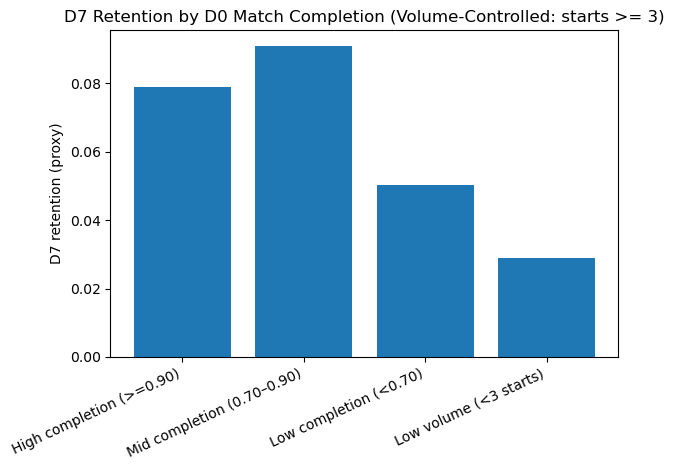

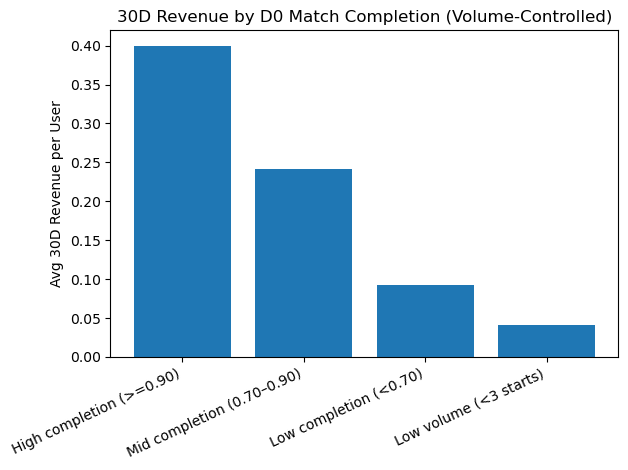

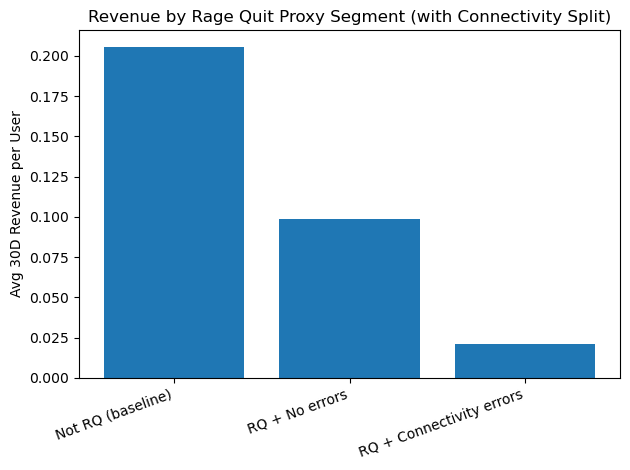

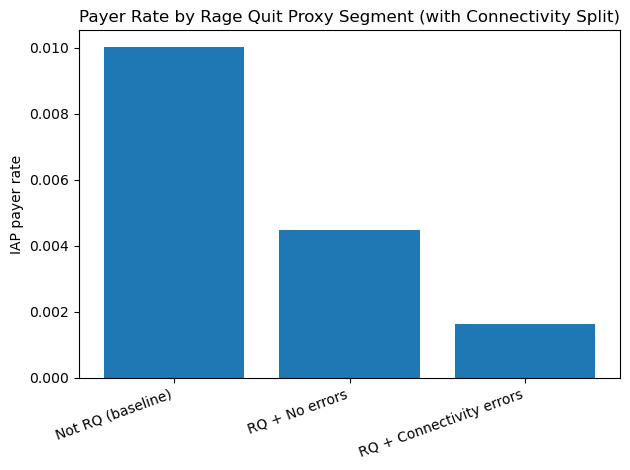


✅ Done (V2). Next: run platform (iOS vs Android) and country-tier breakdowns on these segments.


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# Idea 1 (V2): Volume-controlled completion + Rage-quit x Connectivity + Lifts
# ----------------------------

df = game_data.copy()

# --- Parameters you can tune (and mention in README) ---
HORIZON_DAYS = 30
MIN_MATCHES_FOR_COMPLETION = 3     # volume control: only analyze completion rate if user started >=3 matches on D0
RQ_COMPLETION_THRESHOLD = 0.70     # rage quit proxy: completion rate < 0.70 (when enough volume)
TOPN_CROSS = 12                    # how many cross segments to print

# 1) Parse dates + cohort age
df["event_date"] = pd.to_datetime(df["event_date"], errors="coerce")
df["install_date"] = pd.to_datetime(df["install_date"], errors="coerce")
df = df.dropna(subset=["event_date", "install_date"])

df["days_since_install"] = (df["event_date"] - df["install_date"]).dt.days.astype("int16")

# Keep only users within horizon
dfh = df[(df["days_since_install"] >= 0) & (df["days_since_install"] <= (HORIZON_DAYS - 1))].copy()

# Optional memory reduction
for col in ["platform", "country"]:
    if col in dfh.columns:
        dfh[col] = dfh[col].astype("category")

# 2) Build D0 features per user
d0 = dfh[dfh["days_since_install"] == 0].copy()

d0_agg = d0.groupby("user_id", as_index=False).agg(
    platform=("platform", "first"),
    country=("country", "first"),
    total_session_count_d0=("total_session_count", "sum"),
    total_session_duration_d0=("total_session_duration", "sum"),
    match_start_count_d0=("match_start_count", "sum"),
    match_end_count_d0=("match_end_count", "sum"),
    victory_count_d0=("victory_count", "sum"),
    defeat_count_d0=("defeat_count", "sum"),
    server_connection_error_d0=("server_connection_error", "sum"),
    iap_revenue_d0=("iap_revenue", "sum"),
    ad_revenue_d0=("ad_revenue", "sum"),
)

# Ratios
starts = d0_agg["match_start_count_d0"].astype("float64")
ends = d0_agg["match_end_count_d0"].astype("float64")
d0_agg["completion_rate_d0"] = np.where(starts > 0, ends / starts, np.nan)

wins = d0_agg["victory_count_d0"].astype("float64")
losses = d0_agg["defeat_count_d0"].astype("float64")
den = wins + losses
d0_agg["win_rate_d0"] = np.where(den > 0, wins / den, np.nan)

d0_agg["connectivity_flag_d0"] = (d0_agg["server_connection_error_d0"] > 0).astype("int8")

# 3) Outcomes per user (retention proxy + revenue within horizon)
dfh["is_d7"] = (dfh["days_since_install"] == 7).astype("int8")
dfh["is_d14"] = (dfh["days_since_install"] == 14).astype("int8")
dfh["total_revenue"] = dfh["iap_revenue"].fillna(0) + dfh["ad_revenue"].fillna(0)

outcomes = dfh.groupby("user_id", as_index=False).agg(
    retained_d7=("is_d7", "max"),
    retained_d14=("is_d14", "max"),
    active_days_h=("event_date", "nunique"),
    iap_rev_h=("iap_revenue", "sum"),
    ad_rev_h=("ad_revenue", "sum"),
    revenue_h=("total_revenue", "sum"),
)

outcomes["iap_payer_h"] = (outcomes["iap_rev_h"] > 0).astype("int8")

# 4) Merge
user = d0_agg.merge(outcomes, on="user_id", how="inner")

# 5) Volume-controlled completion segmentation
# Define buckets ONLY for users with enough match volume; others go to "Low volume" bucket
def completion_bucket_vol(row):
    starts = row["match_start_count_d0"]
    cr = row["completion_rate_d0"]
    if starts < MIN_MATCHES_FOR_COMPLETION:
        return f"Low volume (<{MIN_MATCHES_FOR_COMPLETION} starts)"
    if pd.isna(cr):
        return "Unknown completion"
    if cr < 0.70:
        return "Low completion (<0.70)"
    if cr < 0.90:
        return "Mid completion (0.70–0.90)"
    return "High completion (>=0.90)"

user["completion_bucket_vc"] = user.apply(completion_bucket_vol, axis=1)

# Win-rate bucket (same as before; but will be used for cross-tab)
def win_bucket(x):
    if pd.isna(x):
        return "No outcome (D0)"
    if x < 0.40:
        return "Low win (<0.40)"
    if x <= 0.60:
        return "Mid win (0.40–0.60)"
    return "High win (>0.60)"

user["win_bucket"] = user["win_rate_d0"].apply(win_bucket)

# 6) Rage-quit proxy (volume-controlled) + connectivity split
# Rage quit proxy: enough matches AND low completion
user["rage_quit_proxy_vc"] = (
    (user["match_start_count_d0"] >= MIN_MATCHES_FOR_COMPLETION) &
    (user["completion_rate_d0"].fillna(1.0) < RQ_COMPLETION_THRESHOLD)
).astype("int8")

def rq_connectivity_segment(row):
    if row["rage_quit_proxy_vc"] == 0:
        return "Not RQ (baseline)"
    # RQ == 1
    if row["connectivity_flag_d0"] == 1:
        return "RQ + Connectivity errors"
    return "RQ + No errors"

user["rq_segment"] = user.apply(rq_connectivity_segment, axis=1)

# 7) Baselines (overall)
baseline = {
    "d7": user["retained_d7"].mean(),
    "d14": user["retained_d14"].mean(),
    "rev": user["revenue_h"].mean(),
    "payer": user["iap_payer_h"].mean(),
    "active_days": user["active_days_h"].mean(),
}

def add_lifts(summary_df: pd.DataFrame) -> pd.DataFrame:
    summary_df = summary_df.copy()
    summary_df["d7_lift"] = np.where(baseline["d7"] > 0, summary_df["d7_retention"] / baseline["d7"], np.nan)
    summary_df["d14_lift"] = np.where(baseline["d14"] > 0, summary_df["d14_retention"] / baseline["d14"], np.nan)
    summary_df["rev_lift"] = np.where(baseline["rev"] > 0, summary_df["avg_revenue_h"] / baseline["rev"], np.nan)
    summary_df["payer_lift"] = np.where(baseline["payer"] > 0, summary_df["payer_rate_h"] / baseline["payer"], np.nan)
    return summary_df

print("=== Overall Baselines (within horizon) ===")
print(
    f"D7: {baseline['d7']:.4f} | D14: {baseline['d14']:.4f} | "
    f"AvgRev: {baseline['rev']:.4f} | PayerRate: {baseline['payer']:.4f} | "
    f"AvgActiveDays: {baseline['active_days']:.2f}"
)

# 8) Summary: Volume-controlled completion bucket
summary_comp = user.groupby("completion_bucket_vc").agg(
    users=("user_id", "nunique"),
    d7_retention=("retained_d7", "mean"),
    d14_retention=("retained_d14", "mean"),
    avg_revenue_h=("revenue_h", "mean"),
    avg_iap_h=("iap_rev_h", "mean"),
    avg_ad_h=("ad_rev_h", "mean"),
    payer_rate_h=("iap_payer_h", "mean"),
    avg_active_days_h=("active_days_h", "mean"),
).reset_index()

# Sort for readability: show meaningful buckets first
bucket_order = [
    "High completion (>=0.90)",
    "Mid completion (0.70–0.90)",
    "Low completion (<0.70)",
    f"Low volume (<{MIN_MATCHES_FOR_COMPLETION} starts)",
    "Unknown completion",
]
summary_comp["order"] = summary_comp["completion_bucket_vc"].apply(lambda x: bucket_order.index(x) if x in bucket_order else 999)
summary_comp = summary_comp.sort_values(["order", "users"], ascending=[True, False]).drop(columns=["order"])

summary_comp = add_lifts(summary_comp)

print("\n=== Volume-Controlled Completion Summary (D0 -> D7/D14 + Monetization) ===")
print(summary_comp.to_string(index=False))

# 9) Summary: Rage quit x connectivity segment
summary_rq = user.groupby("rq_segment").agg(
    users=("user_id", "nunique"),
    d7_retention=("retained_d7", "mean"),
    d14_retention=("retained_d14", "mean"),
    avg_revenue_h=("revenue_h", "mean"),
    payer_rate_h=("iap_payer_h", "mean"),
    avg_active_days_h=("active_days_h", "mean"),
).reset_index()

# Sort
rq_order = ["Not RQ (baseline)", "RQ + No errors", "RQ + Connectivity errors"]
summary_rq["order"] = summary_rq["rq_segment"].apply(lambda x: rq_order.index(x) if x in rq_order else 999)
summary_rq = summary_rq.sort_values(["order"]).drop(columns=["order"])

summary_rq = add_lifts(summary_rq)

print("\n=== Rage Quit Proxy (Volume-Controlled) + Connectivity Split ===")
print(summary_rq.to_string(index=False))

# 10) Cross-tab: Completion x Win (only for enough match volume)
user_vc = user[user["match_start_count_d0"] >= MIN_MATCHES_FOR_COMPLETION].copy()

cross = user_vc.groupby(["completion_bucket_vc", "win_bucket"]).agg(
    users=("user_id", "nunique"),
    d7_retention=("retained_d7", "mean"),
    avg_revenue_h=("revenue_h", "mean"),
    payer_rate_h=("iap_payer_h", "mean"),
).reset_index().sort_values("users", ascending=False)

print(f"\n=== Completion x Win (volume-controlled, top {TOPN_CROSS} by users) ===")
print(cross.head(TOPN_CROSS).to_string(index=False))

# 11) Plots (readable, story-ready)

# (A) D7 retention by completion bucket (volume-controlled)
plt.figure()
plt.bar(summary_comp["completion_bucket_vc"], summary_comp["d7_retention"])
plt.xticks(rotation=25, ha="right")
plt.ylabel("D7 retention (proxy)")
plt.title(f"D7 Retention by D0 Match Completion (Volume-Controlled: starts >= {MIN_MATCHES_FOR_COMPLETION})")
plt.tight_layout()
plt.show()

# (B) Avg revenue by completion bucket (volume-controlled)
plt.figure()
plt.bar(summary_comp["completion_bucket_vc"], summary_comp["avg_revenue_h"])
plt.xticks(rotation=25, ha="right")
plt.ylabel(f"Avg {HORIZON_DAYS}D Revenue per User")
plt.title(f"{HORIZON_DAYS}D Revenue by D0 Match Completion (Volume-Controlled)")
plt.tight_layout()
plt.show()

# (C) Rage quit segment: revenue + payer rate (two plots for clarity)
plt.figure()
plt.bar(summary_rq["rq_segment"], summary_rq["avg_revenue_h"])
plt.xticks(rotation=20, ha="right")
plt.ylabel(f"Avg {HORIZON_DAYS}D Revenue per User")
plt.title("Revenue by Rage Quit Proxy Segment (with Connectivity Split)")
plt.tight_layout()
plt.show()

plt.figure()
plt.bar(summary_rq["rq_segment"], summary_rq["payer_rate_h"])
plt.xticks(rotation=20, ha="right")
plt.ylabel("IAP payer rate")
plt.title("Payer Rate by Rage Quit Proxy Segment (with Connectivity Split)")
plt.tight_layout()
plt.show()

print("\n✅ Done (V2). Next: run platform (iOS vs Android) and country-tier breakdowns on these segments.")


WINDOW D0 (days 0-0) | High-value threshold: revenue_30d >= 0.0958
High-value base rate: 0.1000

--- Model: behavior_only | Window: D0 ---
AUC=0.8240 | PR-AUC=0.3582
Top10% segment (test): Precision=0.4054 Recall=0.4485 F1=0.4258 | Lift=4.05x
Base high-value rate=0.1000 | Top-segment high-value rate=0.4054

Top readable leaf rules (train-derived):
1) HV rate~0.938 | support~26572 | IF total_session_duration_d0 > 1225.4975 AND total_session_duration_d0 > 2591.9980 AND platform_ios > 0.5000
2) HV rate~0.805 | support~67397 | IF total_session_duration_d0 > 1225.4975 AND total_session_duration_d0 > 2591.9980 AND platform_ios <= 0.5000
3) HV rate~0.773 | support~39430 | IF total_session_duration_d0 > 1225.4975 AND total_session_duration_d0 <= 2591.9980 AND country_tier_Tier1_high > 0.5000
4) HV rate~0.593 | support~44086 | IF total_session_duration_d0 <= 1225.4975 AND total_session_duration_d0 > 568.1405 AND country_tier_Tier1_high > 0.5000
5) HV rate~0.537 | support~118281 | IF total_sess

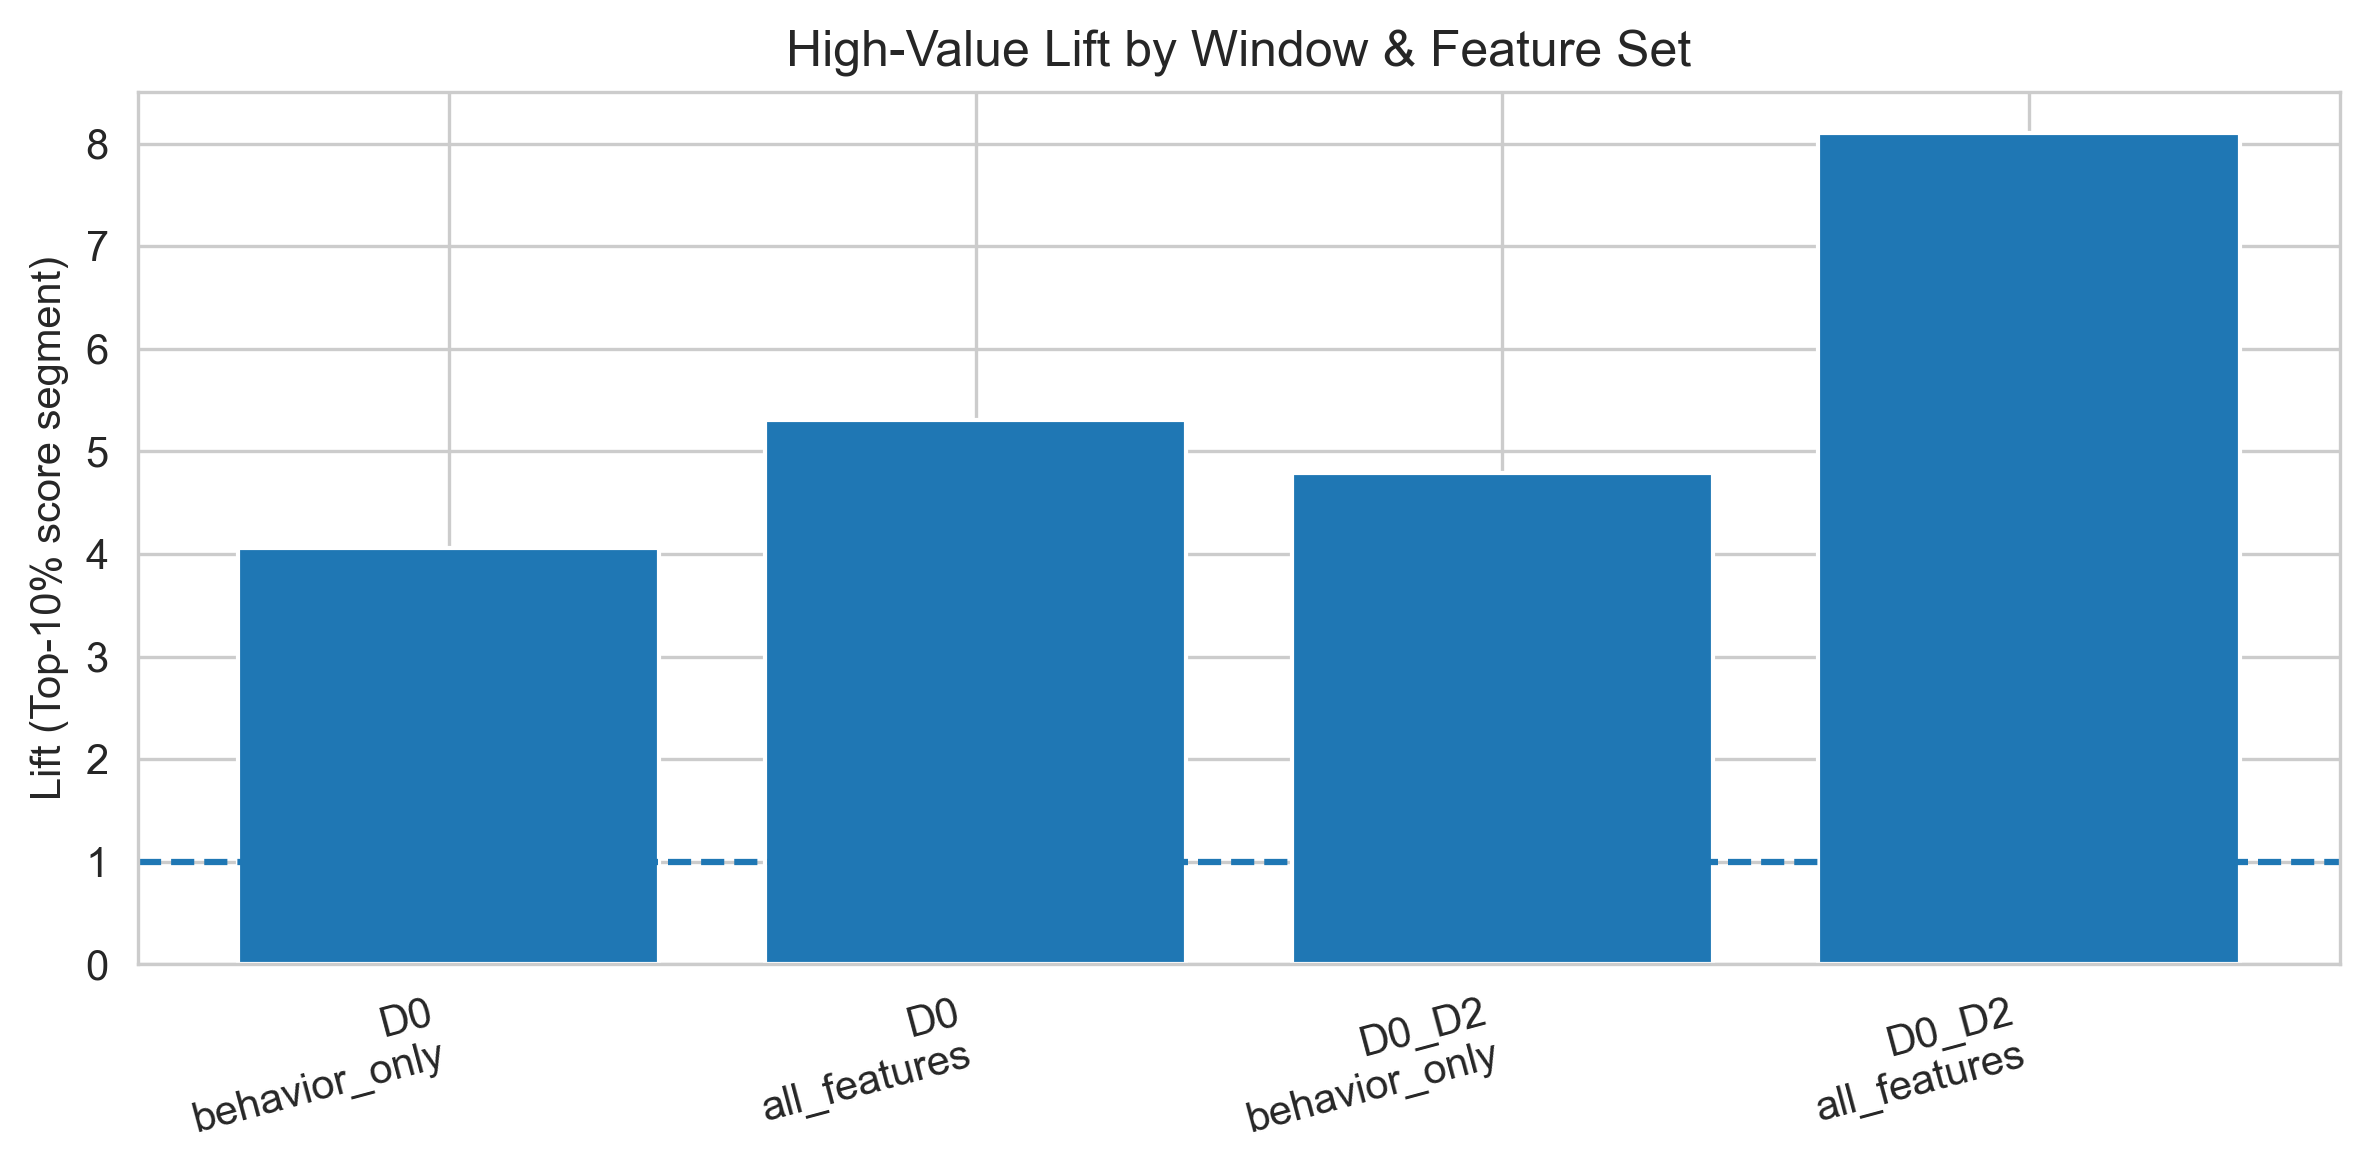

In [7]:
"""
Aha Moment Analysis (Simplified + Correct)
Goal: Find early behavioral thresholds (via shallow decision trees) that predict
      High-Value users (Top 10% by D30 revenue).
Also compares:
  - Window: D0 vs D0–D2
  - Feature set: Behavior-only vs All-features (includes early monetization)
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_fscore_support


# =========================
# CONFIG
# =========================
HORIZON_DAYS = 30
FEATURE_WINDOWS = {
    "D0": (0, 0),
    "D0_D2": (0, 2),  # first 3 days
}

TREE_MAX_DEPTH = 3
MIN_SAMPLES_LEAF = 2000
TEST_SIZE = 0.20
RANDOM_STATE = 42
TOP_VALUE_PERCENTILE = 0.90
MIN_USERS_PER_COUNTRY = 5000


# =========================
# HELPERS
# =========================
def tier_countries_by_avg_rev(user_df: pd.DataFrame, min_users: int = MIN_USERS_PER_COUNTRY) -> dict:
    """Tier countries by avg revenue_30d using only this dataset."""
    cs = user_df.groupby("country", as_index=False).agg(
        users=("user_id", "nunique"),
        avg_rev=("revenue_30d", "mean"),
    )
    eligible = cs[cs["users"] >= min_users].copy()
    if eligible.empty:
        return {}

    q1, q2 = eligible["avg_rev"].quantile([0.33, 0.66]).values

    def tier(x):
        if x <= q1:
            return "Tier3_low"
        if x <= q2:
            return "Tier2_mid"
        return "Tier1_high"

    eligible["country_tier"] = eligible["avg_rev"].apply(tier)
    return dict(zip(eligible["country"], eligible["country_tier"]))


def extract_window_features(dfh: pd.DataFrame, day_min: int, day_max: int, suffix: str) -> pd.DataFrame:
    """Aggregate user features over [day_min, day_max] since install."""
    w = dfh[dfh["days_since_install"].between(day_min, day_max)].copy()

    feats = w.groupby("user_id", as_index=False).agg(
        platform=("platform", "first"),
        country=("country", "first"),

        **{
            f"total_session_count_{suffix}": ("total_session_count", "sum"),
            f"total_session_duration_{suffix}": ("total_session_duration", "sum"),
            f"match_start_count_{suffix}": ("match_start_count", "sum"),
            f"match_end_count_{suffix}": ("match_end_count", "sum"),
            f"victory_count_{suffix}": ("victory_count", "sum"),
            f"defeat_count_{suffix}": ("defeat_count", "sum"),
            f"server_connection_error_{suffix}": ("server_connection_error", "sum"),
            f"iap_revenue_{suffix}": ("iap_revenue", "sum"),
            f"ad_revenue_{suffix}": ("ad_revenue", "sum"),
        }
    )

    # Derived metrics
    starts = feats[f"match_start_count_{suffix}"].astype("float64")
    ends = feats[f"match_end_count_{suffix}"].astype("float64")
    feats[f"completion_rate_{suffix}"] = np.where(starts > 0, ends / starts, 0.0)

    wins = feats[f"victory_count_{suffix}"].astype("float64")
    losses = feats[f"defeat_count_{suffix}"].astype("float64")
    den = wins + losses
    feats[f"win_rate_{suffix}"] = np.where(den > 0, wins / den, 0.0)

    sess = feats[f"total_session_count_{suffix}"].astype("float64")
    feats[f"duration_per_session_{suffix}"] = np.where(
        sess > 0, feats[f"total_session_duration_{suffix}"] / sess, 0.0
    )

    # Binary flags
    feats[f"had_server_error_{suffix}"] = (feats[f"server_connection_error_{suffix}"] > 0).astype("int8")
    feats[f"had_iap_{suffix}"] = (feats[f"iap_revenue_{suffix}"] > 0).astype("int8")
    feats[f"had_ad_{suffix}"] = (feats[f"ad_revenue_{suffix}"] > 0).astype("int8")

    return feats


def build_rule_strings(tree_, feature_names, node_id=0, path=None, rules=None):
    if path is None:
        path = []
    if rules is None:
        rules = []

    left = tree_.children_left[node_id]
    right = tree_.children_right[node_id]
    is_leaf = left == right

    if is_leaf:
        # weighted pos rate (fine as a heuristic)
        counts = tree_.value[node_id][0]
        neg, pos = float(counts[0]), float(counts[1])
        total_w = neg + pos if (neg + pos) > 0 else 1.0
        pos_rate_w = pos / total_w

        # REAL (unweighted) sample support
        support = int(tree_.n_node_samples[node_id])

        rules.append((" AND ".join(path) if path else "(root)", pos_rate_w, support))
        return rules

    feat_idx = tree_.feature[node_id]
    thresh = tree_.threshold[node_id]
    feat = feature_names[feat_idx]

    build_rule_strings(tree_, feature_names, left, path + [f"{feat} <= {thresh:.4f}"], rules)
    build_rule_strings(tree_, feature_names, right, path + [f"{feat} > {thresh:.4f}"], rules)
    return rules


def train_and_report(user_df: pd.DataFrame, suffix: str, feature_set: str):
    """
    Train shallow tree for high_value_30d and print:
      - AUC / PR-AUC
      - Top-10% score segment precision/recall/lift (business-friendly)
      - Top rules (train-derived) for interpretability
    """
    # Targets
    y = user_df["high_value_30d"].astype("int8")

    # Numeric features
    behavior_num = [
        f"total_session_count_{suffix}",
        f"total_session_duration_{suffix}",
        f"duration_per_session_{suffix}",
        f"match_start_count_{suffix}",
        f"match_end_count_{suffix}",
        f"completion_rate_{suffix}",
        f"victory_count_{suffix}",
        f"defeat_count_{suffix}",
        f"win_rate_{suffix}",
        f"server_connection_error_{suffix}",
        f"had_server_error_{suffix}",
    ]
    monet_num = [
        f"iap_revenue_{suffix}",
        f"ad_revenue_{suffix}",
        f"had_iap_{suffix}",
        f"had_ad_{suffix}",
    ]

    if feature_set == "behavior_only":
        feature_cols_num = behavior_num
    else:
        feature_cols_num = behavior_num + monet_num

    feature_cols_cat = ["platform", "country_tier"]

    X = user_df[feature_cols_num + feature_cols_cat].copy()
    for c in feature_cols_num:
        X[c] = X[c].fillna(0)

    # ONE split -> aligned labels
    X_train, X_test = train_test_split(
        X, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
    )
    y_train = y.loc[X_train.index]
    y_test = y.loc[X_test.index]

    preprocess = ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(handle_unknown="ignore"), feature_cols_cat),
            ("num", "passthrough", feature_cols_num),
        ]
    )

    tree = DecisionTreeClassifier(
        max_depth=TREE_MAX_DEPTH,
        min_samples_leaf=MIN_SAMPLES_LEAF,
        random_state=RANDOM_STATE,
        class_weight="balanced",
    )

    model = Pipeline(steps=[("prep", preprocess), ("tree", tree)])
    model.fit(X_train, y_train)

    proba = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, proba)
    ap = average_precision_score(y_test, proba)

    # Business framing: take top 10% scored users in TEST set
    cut = np.quantile(proba, 0.90)
    pred_top = (proba >= cut).astype("int8")
    p, r, f1, _ = precision_recall_fscore_support(y_test, pred_top, average="binary", zero_division=0)

    base_rate = float(y_test.mean())
    top_rate = float(y_test[pred_top == 1].mean()) if pred_top.sum() > 0 else np.nan
    lift = top_rate / base_rate if base_rate > 0 else np.nan

    print(f"\n--- Model: {feature_set} | Window: {suffix.upper()} ---")
    print(f"AUC={auc:.4f} | PR-AUC={ap:.4f}")
    print(f"Top10% segment (test): Precision={p:.4f} Recall={r:.4f} F1={f1:.4f} | Lift={lift:.2f}x")
    print(f"Base high-value rate={base_rate:.4f} | Top-segment high-value rate={top_rate:.4f}")

    # Extract a few readable rules (train-derived)
    ohe = model.named_steps["prep"].named_transformers_["cat"]
    cat_names = list(ohe.get_feature_names_out(feature_cols_cat))
    feature_names = cat_names + feature_cols_num

    clf = model.named_steps["tree"]
    rules = build_rule_strings(clf.tree_, feature_names)

    # Sort rules by (pos_rate desc, support desc) and show top 6
    rules_sorted = sorted(rules, key=lambda x: (x[1], x[2]), reverse=True)[:6]
    print("\nTop readable leaf rules (train-derived):")
    for i, (rule, pos_rate, support) in enumerate(rules_sorted, 1):
        print(f"{i}) HV rate~{pos_rate:.3f} | support~{support} | IF {rule}")

    return {"auc": auc, "ap": ap, "lift": lift, "model": model}


# =========================
# MAIN
# =========================
def run_aha_moment_analysis_simplified(game_data: pd.DataFrame):
    df = game_data.copy()

    # Parse + age
    df["event_date"] = pd.to_datetime(df["event_date"], errors="coerce")
    df["install_date"] = pd.to_datetime(df["install_date"], errors="coerce")
    df = df.dropna(subset=["event_date", "install_date"])
    df["days_since_install"] = (df["event_date"] - df["install_date"]).dt.days.astype("int16")

    # Horizon
    dfh = df[(df["days_since_install"] >= 0) & (df["days_since_install"] <= (HORIZON_DAYS - 1))].copy()

    # Outcomes
    dfh["total_revenue"] = dfh["iap_revenue"].fillna(0) + dfh["ad_revenue"].fillna(0)
    outcomes = dfh.groupby("user_id", as_index=False).agg(
        revenue_30d=("total_revenue", "sum"),
        iap_rev_30d=("iap_revenue", "sum"),
        ad_rev_30d=("ad_revenue", "sum"),
        install_date=("install_date", "first"),
    )

    results = []

    for window_name, (dmin, dmax) in FEATURE_WINDOWS.items():
        suffix = window_name.lower()

        feats = extract_window_features(dfh, dmin, dmax, suffix)
        user = feats.merge(outcomes, on="user_id", how="inner")

        # Country tiers (self-contained)
        tier_map = tier_countries_by_avg_rev(user)
        user["country_tier"] = user["country"].map(tier_map).fillna("Other_small")

        # Target: top 10% D30 revenue
        thr = float(user["revenue_30d"].quantile(TOP_VALUE_PERCENTILE))
        user["high_value_30d"] = (user["revenue_30d"] >= thr).astype("int8")

        print("\n" + "=" * 72)
        print(f"WINDOW {window_name} (days {dmin}-{dmax}) | High-value threshold: revenue_30d >= {thr:.4f}")
        print(f"High-value base rate: {user['high_value_30d'].mean():.4f}")
        print("=" * 72)

        # Train two models: behavior-only vs all-features
        for feature_set in ["behavior_only", "all_features"]:
            res = train_and_report(user, suffix=suffix, feature_set=feature_set)
            results.append({
                "window": window_name,
                "feature_set": feature_set,
                "auc": res["auc"],
                "pr_auc": res["ap"],
                "lift_top10": res["lift"],
            })

    # Comparison table + simple plot
    comp = pd.DataFrame(results)
    print("\n=== Comparison Summary ===")
    print(comp.to_string(index=False))

    # Plot lifts
    plt.figure(figsize=(8, 4))
    labels = [f"{r['window']}\n{r['feature_set']}" for r in results]
    lifts = [r["lift_top10"] for r in results]
    plt.bar(labels, lifts)
    plt.axhline(1.0, linestyle="--")
    plt.ylabel("Lift (Top-10% score segment)")
    plt.title("High-Value Lift by Window & Feature Set")
    plt.xticks(rotation=15, ha="right")
    plt.tight_layout()
    plt.show()

    return comp


# Run
comp = run_aha_moment_analysis_simplified(game_data)

=== Baselines ===
D7 retention: 0.0579
D14 retention: 0.0245
Avg 30D revenue: 0.2107
Payer rate (30D): 0.0101


C:\Users\kagan_ntaijui\AppData\Local\Temp\ipykernel_2360\1328843810.py:164: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(user_heat[col]):



=== Top 15 segments by revenue lift (with min users filter) ===
win_bucket match_bucket  users  avg_rev_30d  payer_rate  avg_active_days  d7_retention  d14_retention  d7_lift  d14_lift  rev_lift  payer_lift
     >=70%  18+ matches  31853     3.022527    0.112737         6.456597      0.262456       0.135372 4.530870  5.533394 14.344070   11.172965
    50–70%  18+ matches  28074     1.857948    0.077509         7.116514      0.306191       0.151742 5.285885  6.202524  8.817303    7.681711
    50–70% 8–17 matches  32023     0.395498    0.017269         3.617587      0.112107       0.040627 1.935343  1.660651  1.876924    1.711459
     >=70% 8–17 matches 168274     0.312227    0.017489         3.432360      0.102422       0.040179 1.768153  1.642317  1.481742    1.733311
     >=70%  3–7 matches 287823     0.075261    0.006018         2.266914      0.051824       0.019717 0.894649  0.805942  0.357166    0.596384
    50–70%  3–7 matches 111465     0.041421    0.003822         1.762212     

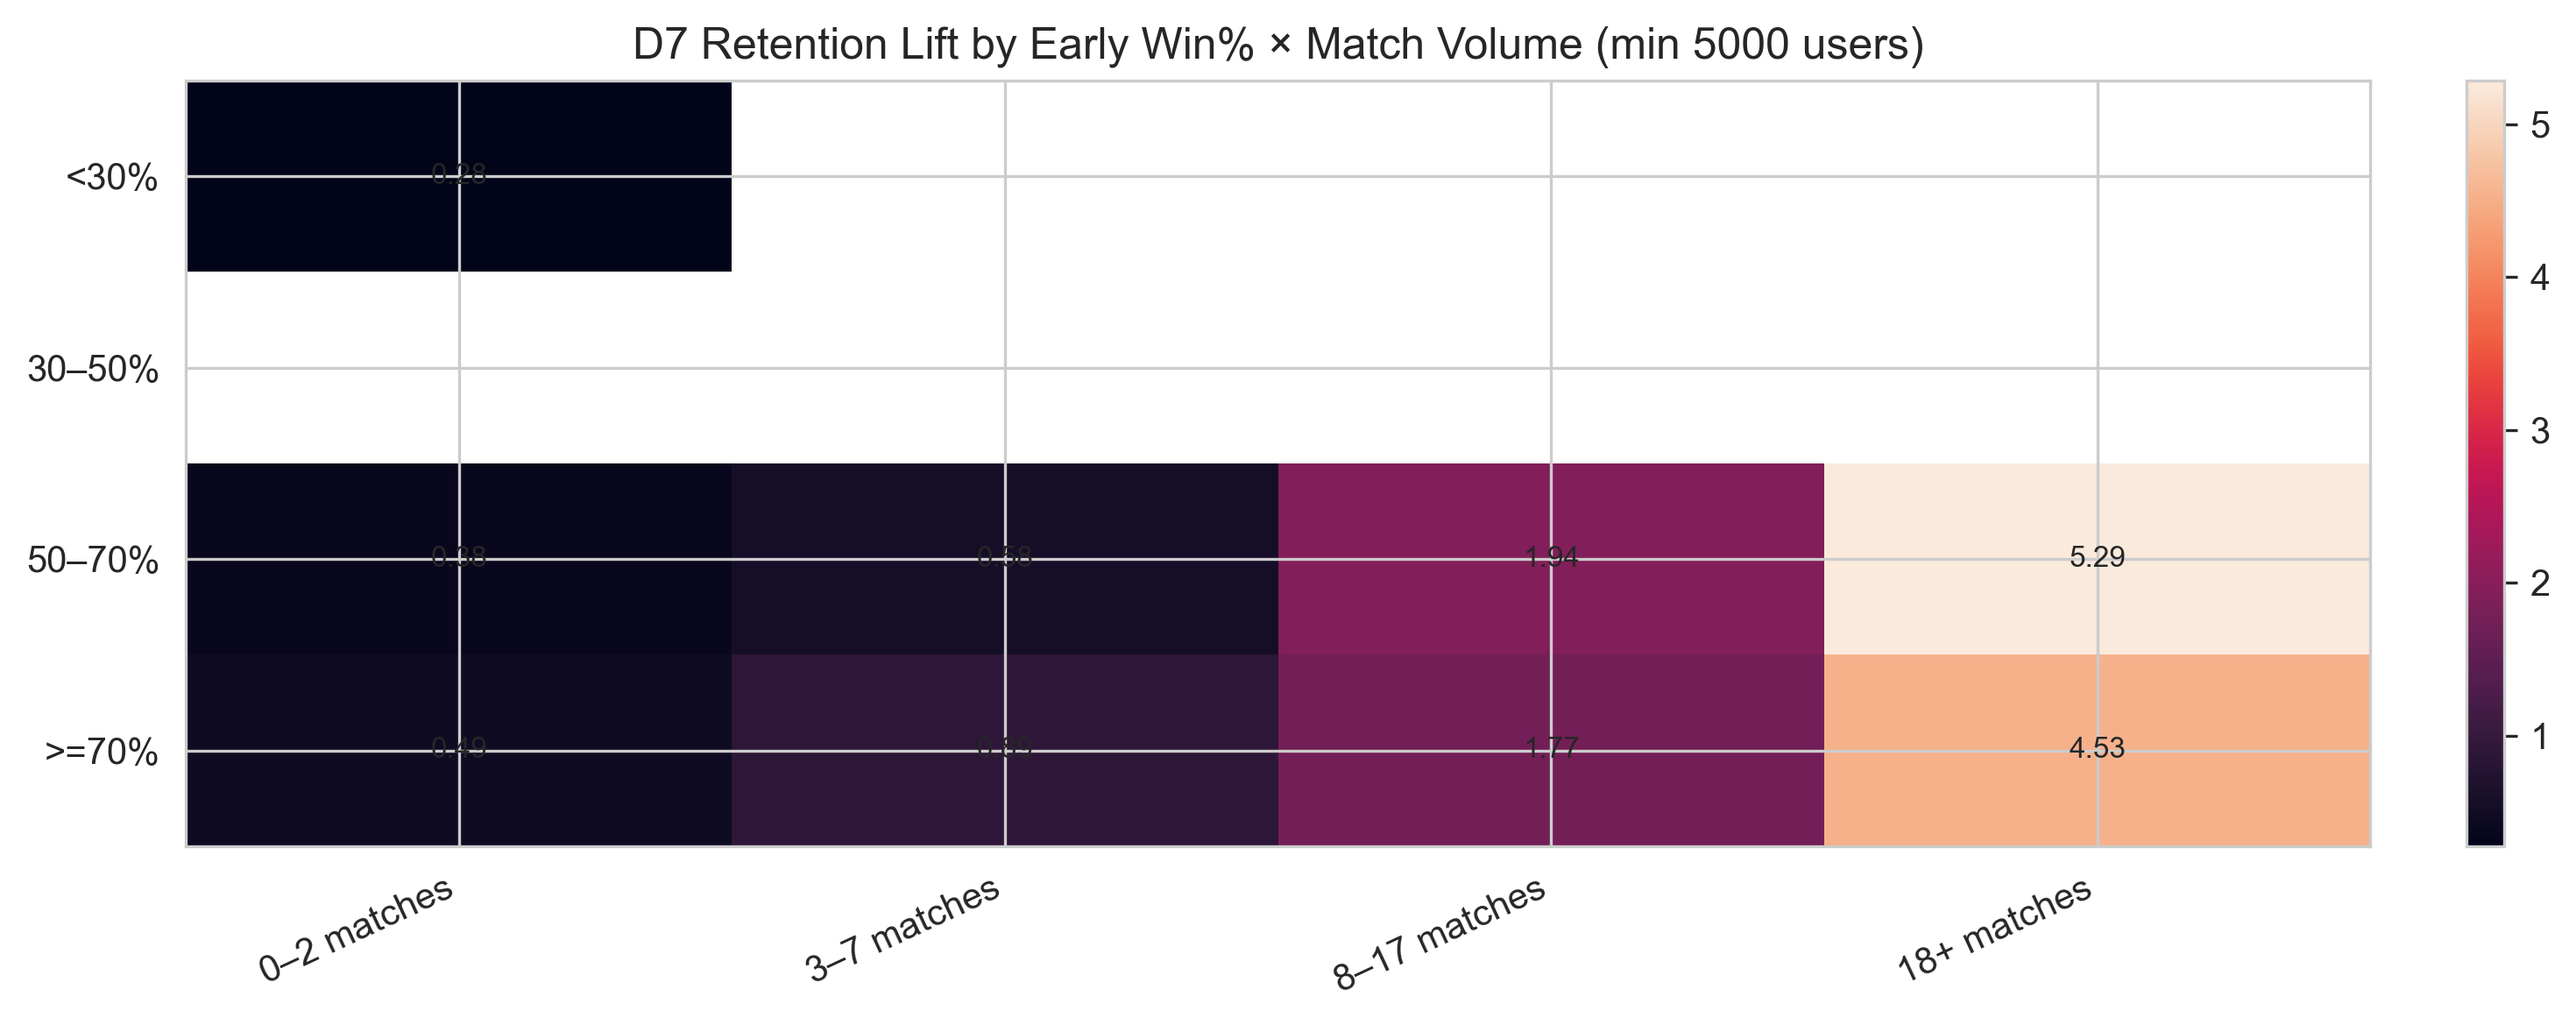

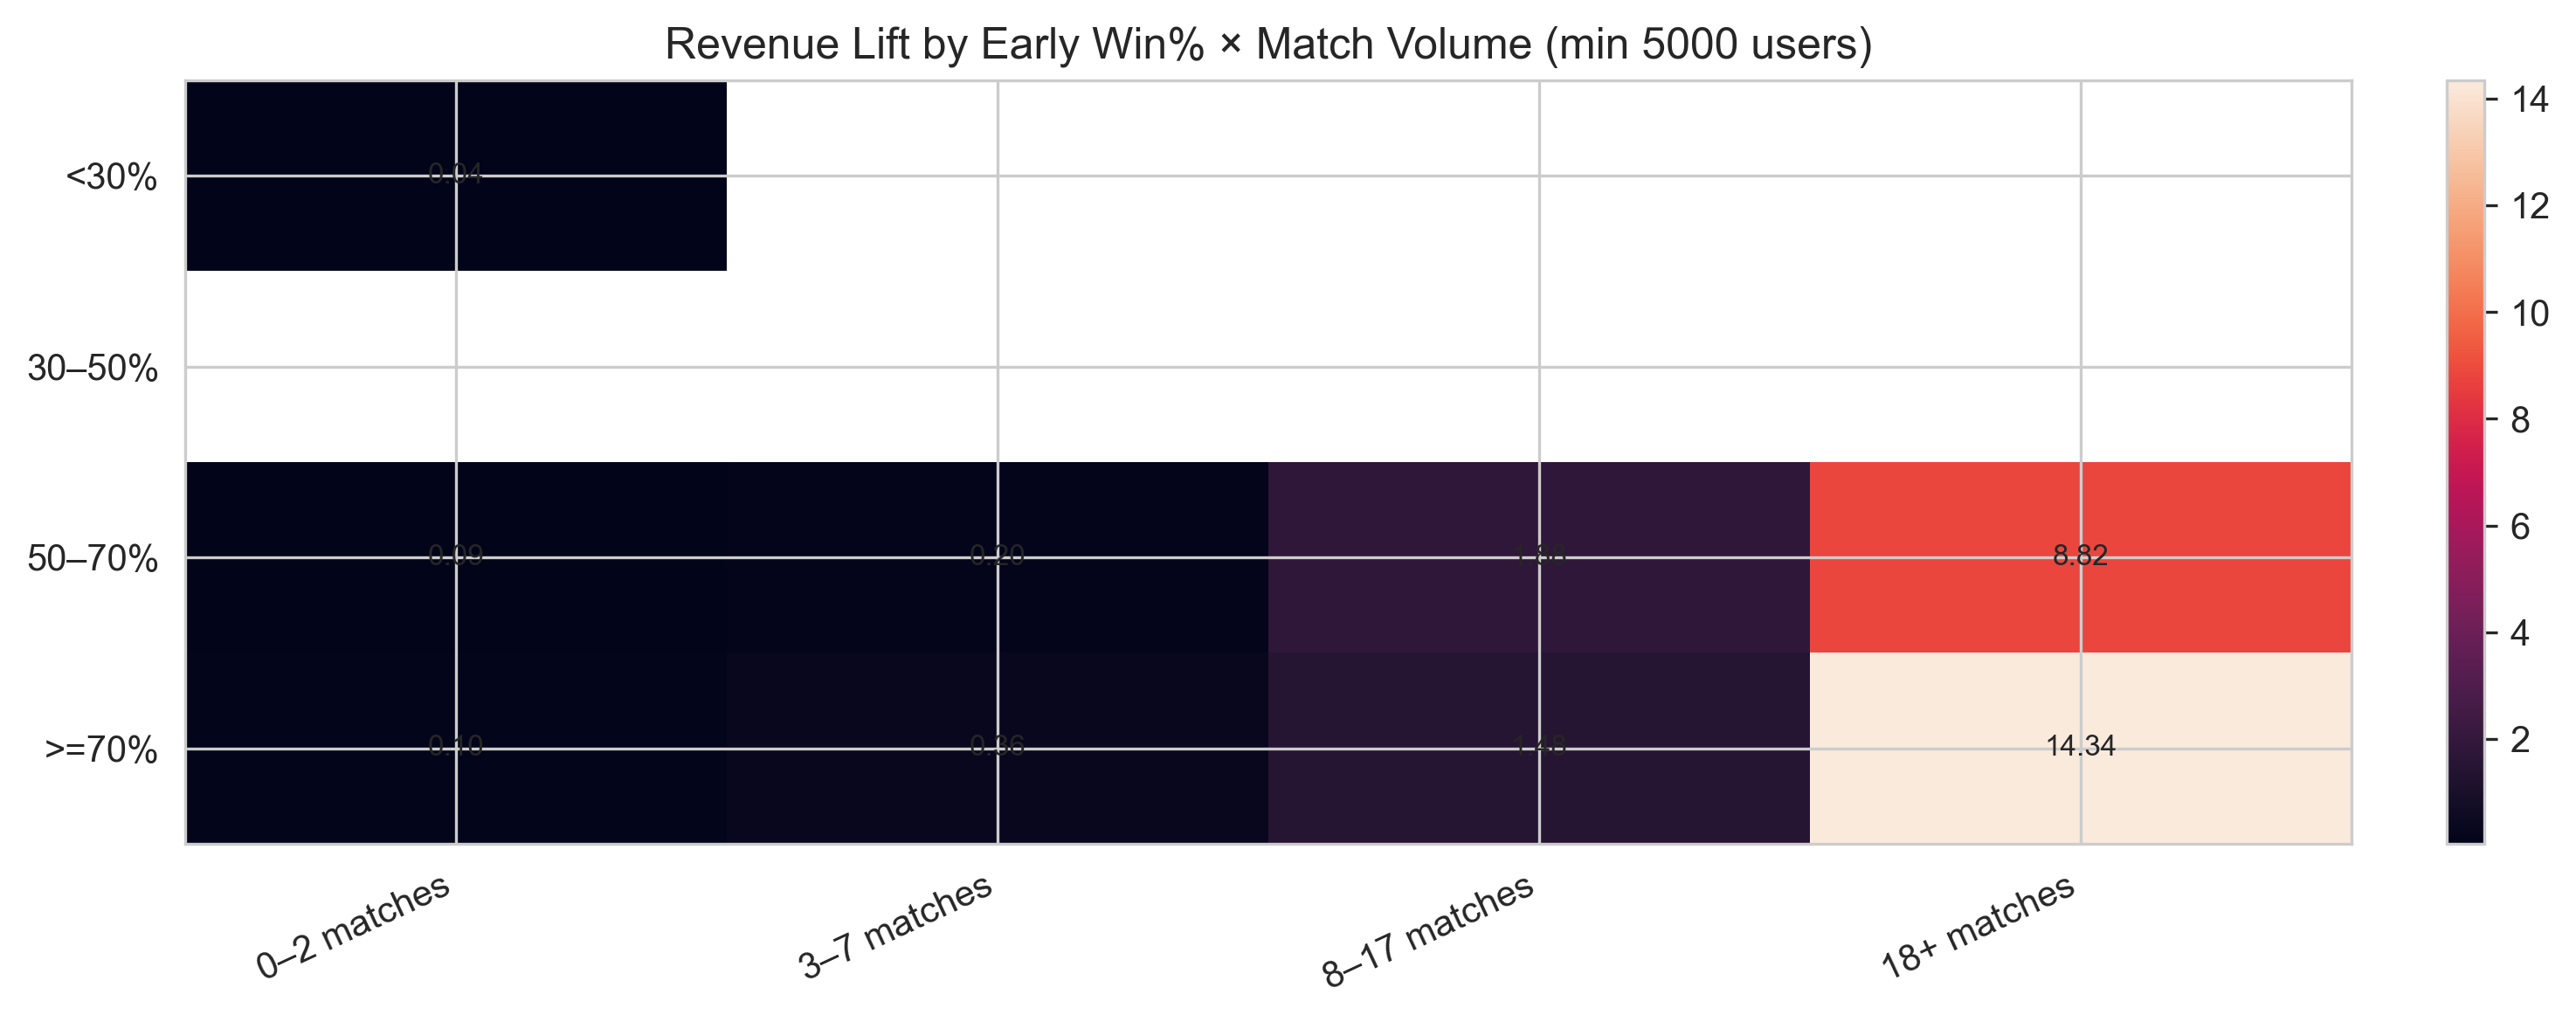

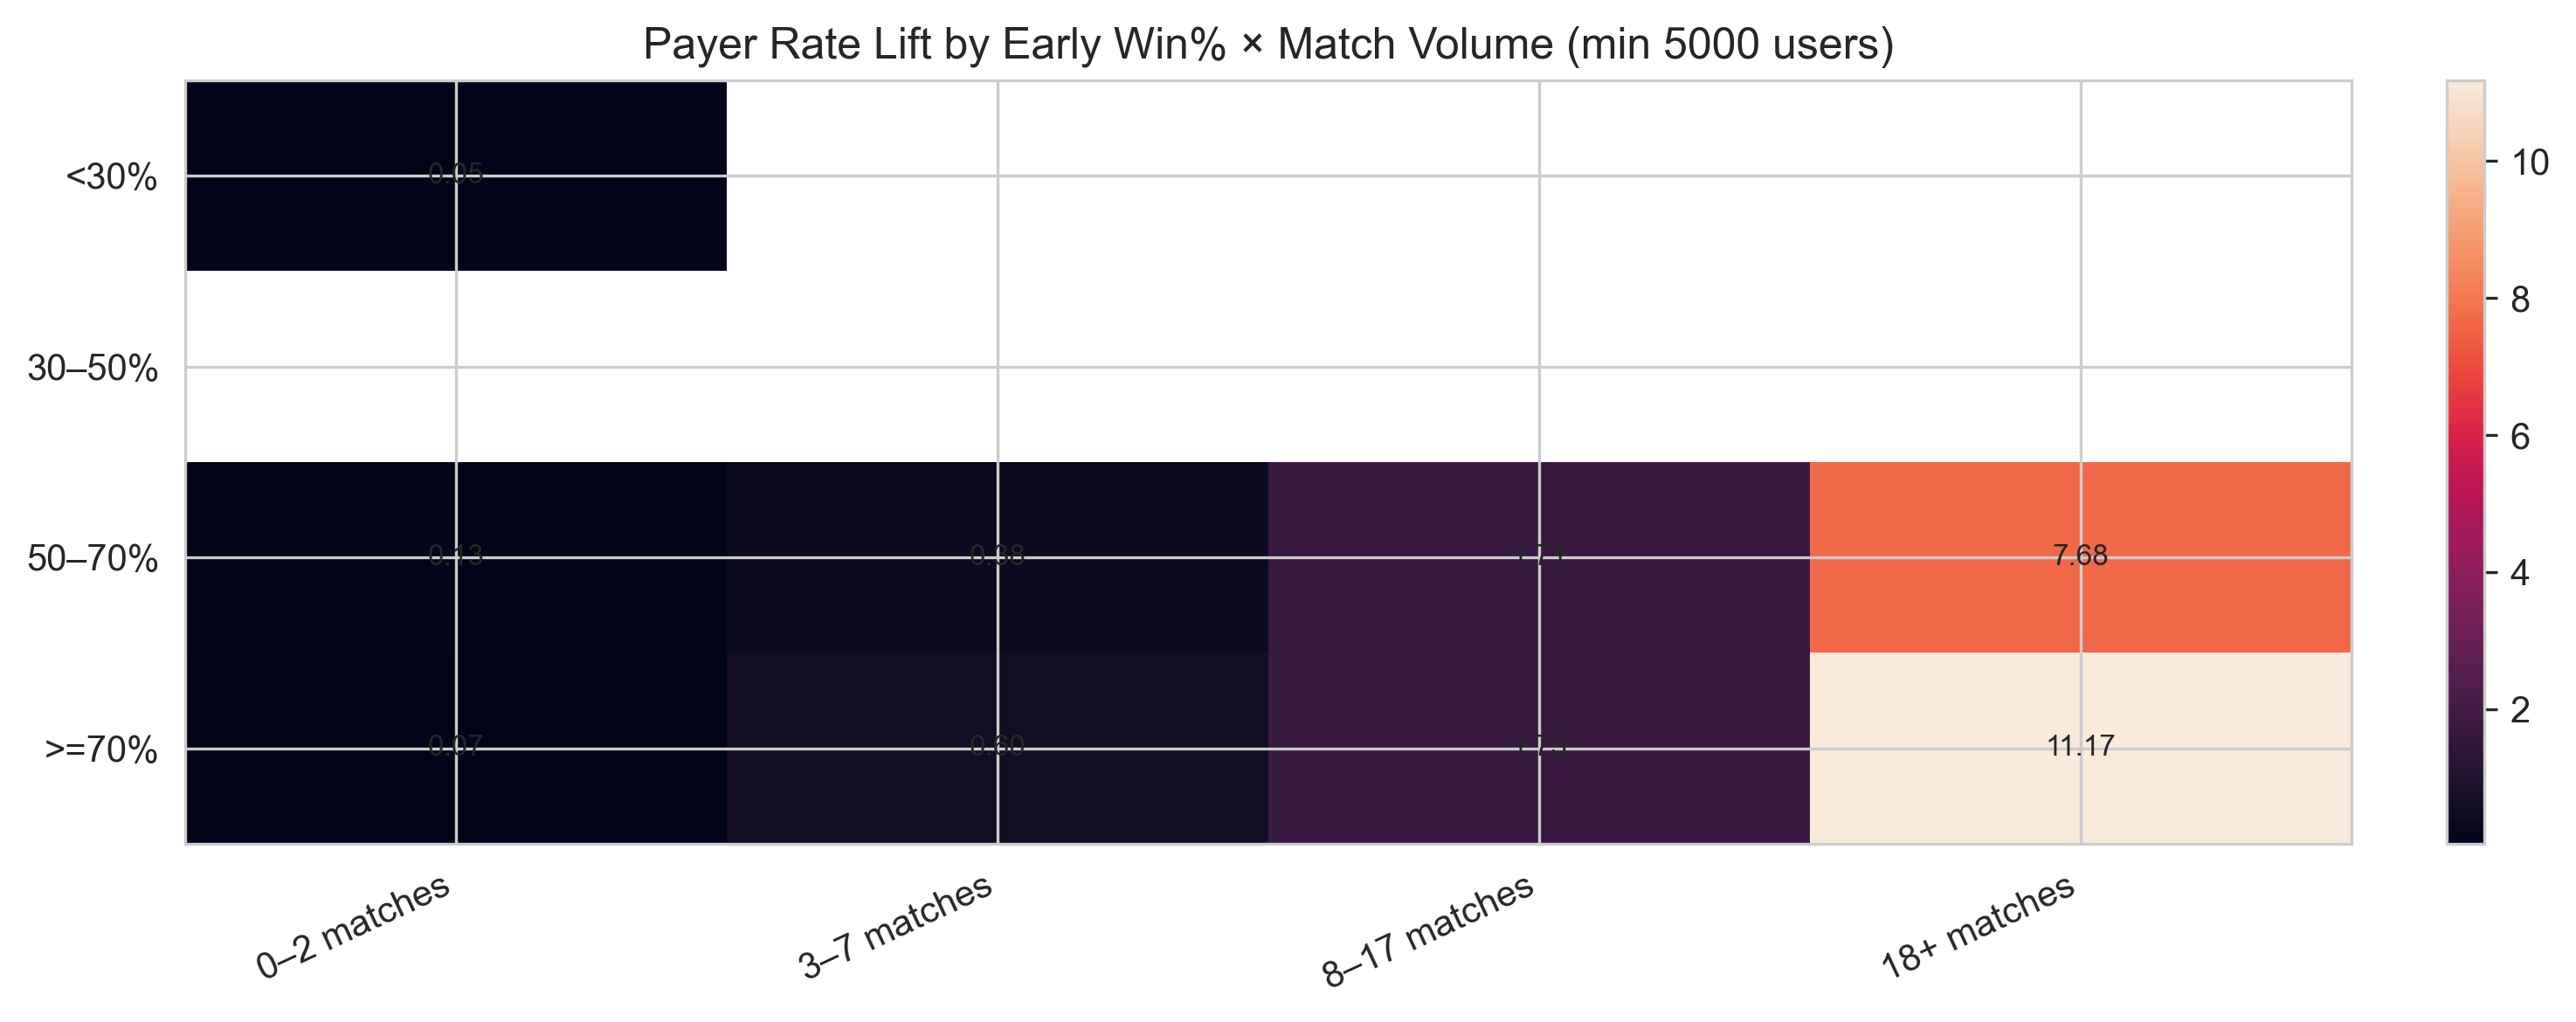


=== Potential Matchmaking Pain Points (low win-rate segments) ===
win_bucket match_bucket  users  avg_rev_30d  payer_rate  avg_active_days  d7_retention  d14_retention  d7_lift  d14_lift  rev_lift  payer_lift
      <30%  0–2 matches 135151      0.00789    0.000481         1.360486      0.016108       0.006408 0.278077  0.261916  0.037444    0.047665

=== High-Value Sweet Spots (high win-rate segments) ===
win_bucket match_bucket  users  avg_rev_30d  payer_rate  avg_active_days  d7_retention  d14_retention  d7_lift  d14_lift  rev_lift  payer_lift
     >=70%  18+ matches  31853     3.022527    0.112737         6.456597      0.262456       0.135372 4.530870  5.533394 14.344070   11.172965
    50–70%  18+ matches  28074     1.857948    0.077509         7.116514      0.306191       0.151742 5.285885  6.202524  8.817303    7.681711
    50–70% 8–17 matches  32023     0.395498    0.017269         3.617587      0.112107       0.040627 1.935343  1.660651  1.876924    1.711459
     >=70% 8–17 ma

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# IDEA 3: "Skill–Engagement Loop" (Win-rate × Match-volume) vs Retention/Value
# For FPS: early wins/losses (matchmaking balance) often drives churn.
# ============================================================

# ----------------------------
# Config
# ----------------------------
HORIZON_DAYS = 30          # outcome horizon for revenue/active days
EARLY_WINDOW = (0, 2)      # use D0-D2 for early skill/engagement signals
RETENTION_DAYS = [7, 14]   # retention proxy checks
MIN_USERS_CELL = 5000      # hide cells with too few users in heatmaps

# Buckets
WIN_BINS = [0.0, 0.30, 0.50, 0.70, 1.0000001]
WIN_LABELS = ["<30%", "30–50%", "50–70%", ">=70%"]

# Match volume buckets are data-driven (quantiles) but with readable labels
MATCH_QUANTILES = [0.0, 0.50, 0.80, 0.95, 1.0]  # low/med/high/very-high

# ----------------------------
# Prep
# ----------------------------
df = game_data.copy()

df["event_date"] = pd.to_datetime(df["event_date"], errors="coerce")
df["install_date"] = pd.to_datetime(df["install_date"], errors="coerce")
df = df.dropna(subset=["event_date", "install_date"])

df["days_since_install"] = (df["event_date"] - df["install_date"]).dt.days.astype("int16")

# keep 0..HORIZON_DAYS-1 for outcomes
dfh = df[(df["days_since_install"] >= 0) & (df["days_since_install"] <= (HORIZON_DAYS - 1))].copy()

# total revenue per row
dfh["total_revenue"] = dfh["iap_revenue"].fillna(0) + dfh["ad_revenue"].fillna(0)

# ----------------------------
# Outcomes per user (within horizon)
# ----------------------------
for d in RETENTION_DAYS:
    dfh[f"is_d{d}"] = (dfh["days_since_install"] == d).astype("int8")

outcomes = dfh.groupby("user_id", as_index=False).agg(
    platform=("platform", "first"),
    country=("country", "first"),
    revenue_30d=("total_revenue", "sum"),
    iap_rev_30d=("iap_revenue", "sum"),
    ad_rev_30d=("ad_revenue", "sum"),
    active_days_30=("event_date", "nunique"),
    **{f"retained_d{d}": (f"is_d{d}", "max") for d in RETENTION_DAYS},
)

outcomes["payer_30d"] = (outcomes["iap_rev_30d"] > 0).astype("int8")

# ----------------------------
# Early window features (skill + engagement)
# ----------------------------
dmin, dmax = EARLY_WINDOW
early = dfh[dfh["days_since_install"].between(dmin, dmax)].copy()

early_agg = early.groupby("user_id", as_index=False).agg(
    total_session_count_early=("total_session_count", "sum"),
    total_session_duration_early=("total_session_duration", "sum"),
    match_start_count_early=("match_start_count", "sum"),
    match_end_count_early=("match_end_count", "sum"),
    victory_count_early=("victory_count", "sum"),
    defeat_count_early=("defeat_count", "sum"),
    server_connection_error_early=("server_connection_error", "sum"),
)

wins = early_agg["victory_count_early"].astype("float64")
losses = early_agg["defeat_count_early"].astype("float64")
den = wins + losses

early_agg["win_rate_early"] = np.where(den > 0, wins / den, np.nan)
early_agg["matches_played_early"] = den  # outcomes-based match count (wins+losses)

# completion rate can help interpret "did they finish matches"
starts = early_agg["match_start_count_early"].astype("float64")
ends = early_agg["match_end_count_early"].astype("float64")
early_agg["completion_rate_early"] = np.where(starts > 0, ends / starts, np.nan)

# duration per session (engagement intensity)
sess = early_agg["total_session_count_early"].astype("float64")
early_agg["duration_per_session_early"] = np.where(sess > 0, early_agg["total_session_duration_early"] / sess, 0.0)

# ----------------------------
# Merge
# ----------------------------
user = early_agg.merge(outcomes, on="user_id", how="inner")

# Basic baseline for reporting
baseline_d7 = user["retained_d7"].mean() if "retained_d7" in user.columns else np.nan
baseline_d14 = user["retained_d14"].mean() if "retained_d14" in user.columns else np.nan
baseline_rev = user["revenue_30d"].mean()
baseline_payer = user["payer_30d"].mean()

print("=== Baselines ===")
if "retained_d7" in user.columns:
    print(f"D7 retention: {baseline_d7:.4f}")
if "retained_d14" in user.columns:
    print(f"D14 retention: {baseline_d14:.4f}")
print(f"Avg 30D revenue: {baseline_rev:.4f}")
print(f"Payer rate (30D): {baseline_payer:.4f}")

# ----------------------------
# Bucket definitions
# ----------------------------
# Win buckets (only for users with at least 1 decided match)
user["win_bucket"] = pd.cut(user["win_rate_early"], bins=WIN_BINS, labels=WIN_LABELS, right=False)

# Match volume buckets (quantile-based for stable cell sizes)
# Use matches_played_early; fill NaN as 0
mp = user["matches_played_early"].fillna(0)

q_edges = mp.quantile(MATCH_QUANTILES).values
# Make edges strictly increasing (guard against degenerate quantiles)
q_edges = np.unique(q_edges)
if len(q_edges) < 5:
    # fallback to fixed bins if quantiles degenerate
    q_edges = np.array([0, 1, 3, 6, 999999], dtype=float)

# ensure last edge is big enough
q_edges[-1] = max(q_edges[-1], mp.max() + 1)

match_labels = []
for i in range(len(q_edges) - 1):
    lo, hi = q_edges[i], q_edges[i + 1]
    if i == len(q_edges) - 2:
        match_labels.append(f"{int(lo)}+ matches")
    else:
        match_labels.append(f"{int(lo)}–{int(hi)-1} matches")

user["match_bucket"] = pd.cut(mp, bins=q_edges, labels=match_labels, right=False, include_lowest=True)

# Drop users without win_bucket (no decided matches) for the heatmap
user_heat = user.dropna(subset=["win_bucket", "match_bucket"]).copy()

# ----------------------------
# Aggregation: Win × Volume grid
# ----------------------------
agg_cols = {
    "users": ("user_id", "nunique"),
    "avg_rev_30d": ("revenue_30d", "mean"),
    "payer_rate": ("payer_30d", "mean"),
    "avg_active_days": ("active_days_30", "mean"),
}

if "retained_d7" in user_heat.columns:
    agg_cols["d7_retention"] = ("retained_d7", "mean")
if "retained_d14" in user_heat.columns:
    agg_cols["d14_retention"] = ("retained_d14", "mean")

# Drop users without buckets (no decided matches)
user_heat = user.dropna(subset=["win_bucket", "match_bucket"]).copy()

# Optional: clean up unused categories (helps pandas behave)
for col in ["win_bucket", "match_bucket"]:
    if pd.api.types.is_categorical_dtype(user_heat[col]):
        user_heat[col] = user_heat[col].cat.remove_unused_categories()

# Aggregation: Win × Volume grid (FIX: observed=True + reset_index)
grid = (
    user_heat
    .groupby(["win_bucket", "match_bucket"], observed=True)
    .agg(**agg_cols)
    .reset_index()
)
# ----------------------------

# Add lifts
if "d7_retention" in grid.columns:
    grid["d7_lift"] = grid["d7_retention"] / baseline_d7 if baseline_d7 > 0 else np.nan
if "d14_retention" in grid.columns:
    grid["d14_lift"] = grid["d14_retention"] / baseline_d14 if baseline_d14 > 0 else np.nan
grid["rev_lift"] = grid["avg_rev_30d"] / baseline_rev if baseline_rev > 0 else np.nan
grid["payer_lift"] = grid["payer_rate"] / baseline_payer if baseline_payer > 0 else np.nan

print("\n=== Top 15 segments by revenue lift (with min users filter) ===")
top = grid[grid["users"] >= MIN_USERS_CELL].sort_values("rev_lift", ascending=False).head(15)
print(top.to_string(index=False))

# ----------------------------
# Heatmap helper (matplotlib, no seaborn)
# ----------------------------
def plot_heatmap(pivot_df, title, fmt="{:.2f}"):
    mat = pivot_df.values.astype(float)
    plt.figure(figsize=(10, 4))
    im = plt.imshow(mat, aspect="auto")
    plt.title(title)
    plt.xticks(range(len(pivot_df.columns)), pivot_df.columns, rotation=25, ha="right")
    plt.yticks(range(len(pivot_df.index)), pivot_df.index)
    plt.colorbar(im, fraction=0.046, pad=0.04)

    # annotate
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            if np.isfinite(mat[i, j]):
                plt.text(j, i, fmt.format(mat[i, j]), ha="center", va="center", fontsize=8)

    plt.tight_layout()
    plt.show()

# Prepare pivots (mask low-support cells)
def pivot_metric(metric):
    p = grid.pivot(index="win_bucket", columns="match_bucket", values=metric)
    counts = grid.pivot(index="win_bucket", columns="match_bucket", values="users")
    p = p.where(counts >= MIN_USERS_CELL)
    return p

# Plot retention (or lifts) and revenue lifts
if "d7_lift" in grid.columns:
    plot_heatmap(pivot_metric("d7_lift"), f"D7 Retention Lift by Early Win% × Match Volume (min {MIN_USERS_CELL} users)")
plot_heatmap(pivot_metric("rev_lift"), f"Revenue Lift by Early Win% × Match Volume (min {MIN_USERS_CELL} users)")
plot_heatmap(pivot_metric("payer_lift"), f"Payer Rate Lift by Early Win% × Match Volume (min {MIN_USERS_CELL} users)")

# ----------------------------
# Business-friendly summary: "problem zones" and "sweet spots"
# ----------------------------
# Define a "problem zone": low win rate + high volume (players grinding but losing)
problem = grid[
    (grid["users"] >= MIN_USERS_CELL) &
    (grid["win_bucket"] == "<30%")
].sort_values("d7_retention" if "d7_retention" in grid.columns else "rev_lift", ascending=True).head(5)

print("\n=== Potential Matchmaking Pain Points (low win-rate segments) ===")
print(problem.to_string(index=False))

sweet = grid[
    (grid["users"] >= MIN_USERS_CELL) &
    (grid["win_bucket"].isin([">=70%", "50–70%"]))
].sort_values("rev_lift", ascending=False).head(5)

print("\n=== High-Value Sweet Spots (high win-rate segments) ===")
print(sweet.to_string(index=False))

print("\n✅ Done. Next optional step: run the same grid split by platform or by country_tier to find where matchmaking issues are worst.")


=== Baselines (30D horizon) ===
Users: 1,446,296
Avg total rev/user: 0.2510 (IAP 0.1960 + Ad 0.0549)
Payer rate: 0.0113 | Ad-monetizer rate: 0.4097

=== Tier thresholds (among >0 users) ===
IAP: Dolphin>= 63.2203, Whale>= 256.0439
Ad : Dolphin>= 0.5233, Whale>= 1.8045
Tot: Dolphin>= 0.7363, Whale>= 6.3862

=== Monetization Mix Archetypes (overall) ===
mix_archetype  users  share_users     total_rev  share_rev   avg_rev   avg_iap   avg_ad  payer_rate  ad_monet_rate  avg_ad_share  avg_active_days
 IAP-dominant  11184     0.007733 278059.214465   0.766017 24.862233 24.469080 0.393154    1.000000       0.742489      0.047847         8.340576
  Ad-dominant 579513     0.400688  68416.292957   0.188478  0.118058  0.000374 0.117685    0.000544       1.000000      0.999928         3.476302
       Hybrid   4798     0.003317  16518.102158   0.045505  3.442706  2.011679 1.431027    1.000000       1.000000      0.430203         9.957691
Non-monetizer 850801     0.588262      0.000000   0.000000  0.

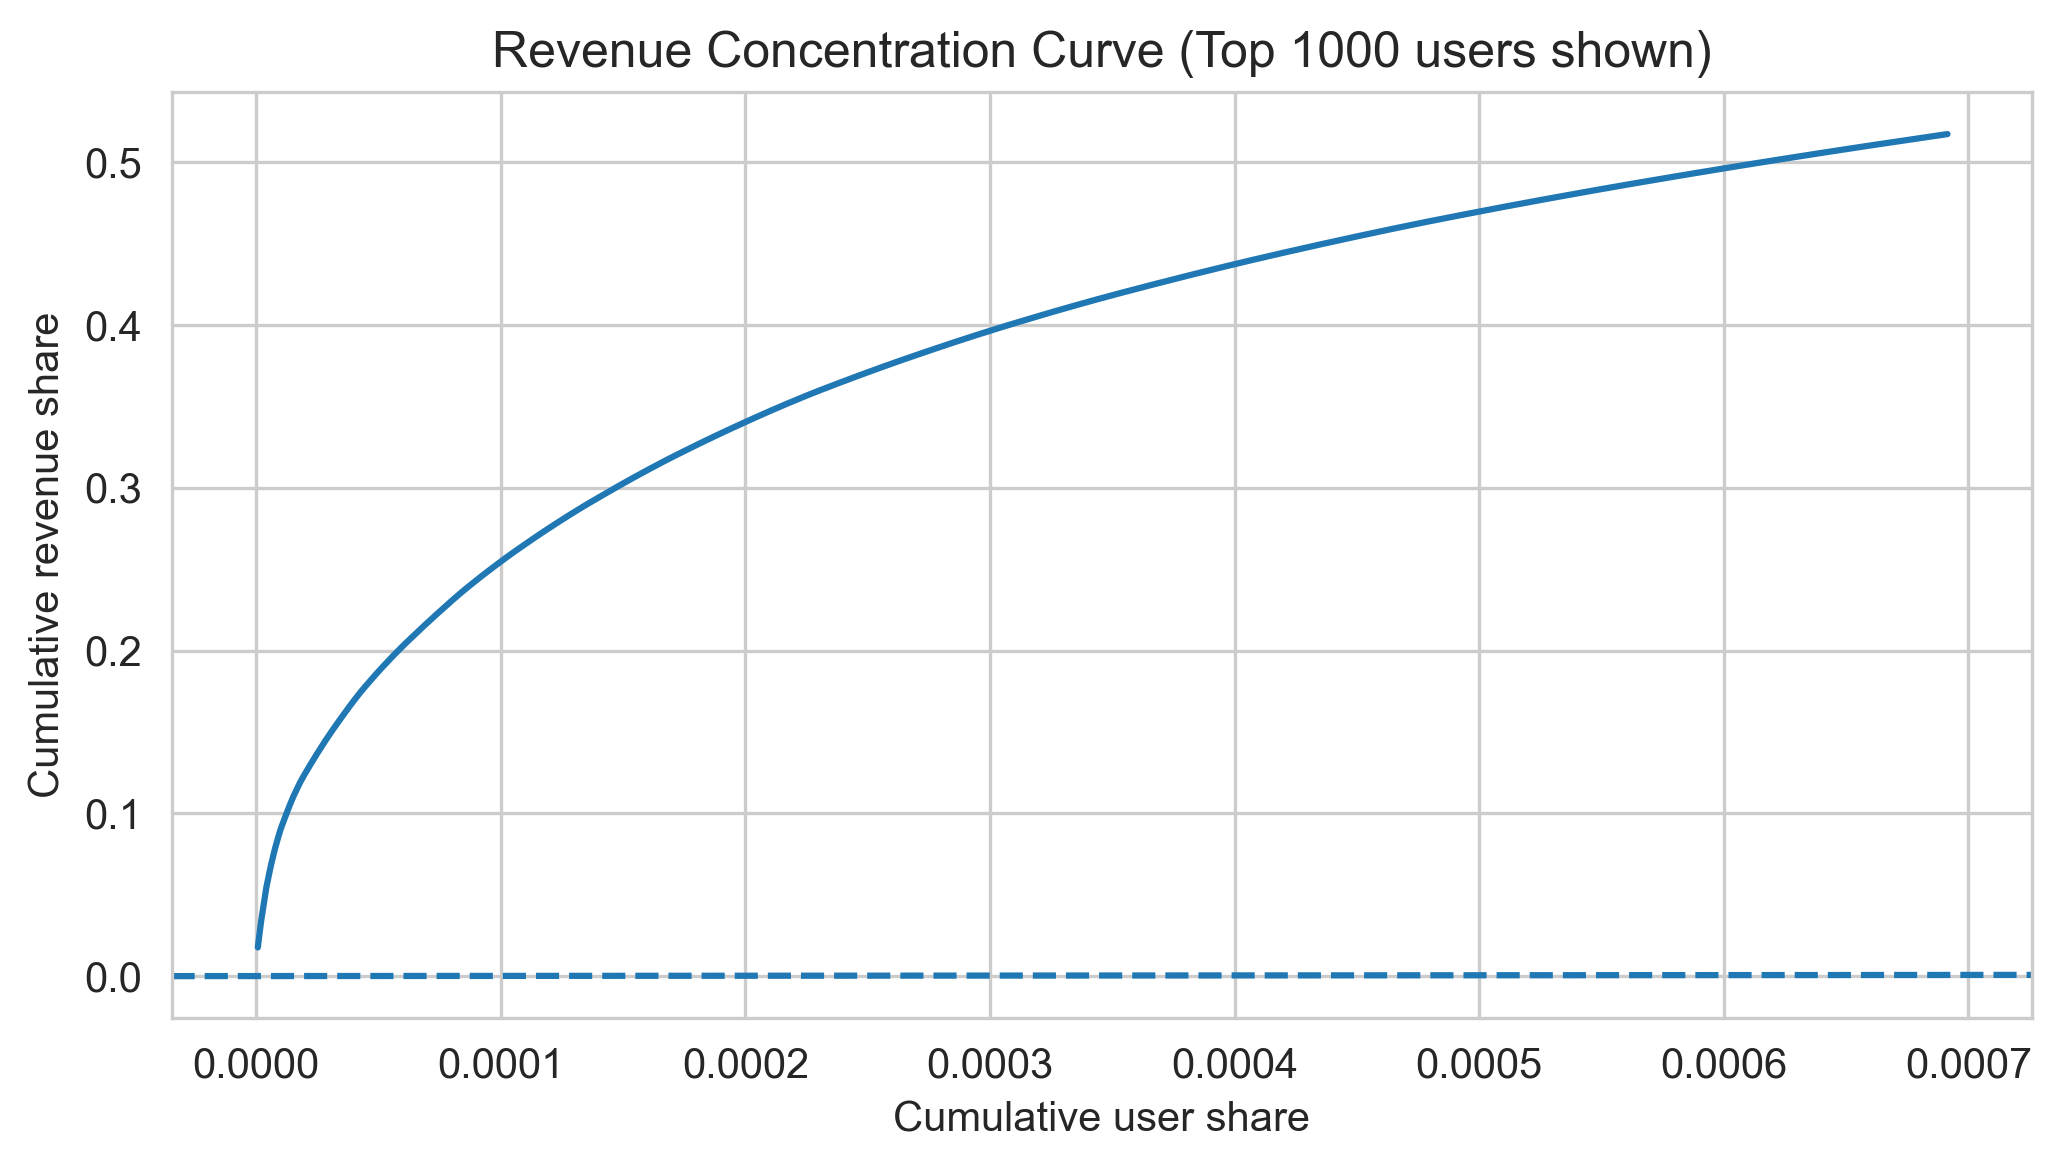


=== Total Whales: Driver × Platform × Country Tier (top rows) ===
whale_driver platform country_tier  users  avg_total   avg_iap    avg_ad  avg_ad_share
  IAP-driven      ios   Tier1_high   1671  58.198117 57.194422  1.003695      0.052483
  IAP-driven  android   Tier1_high   1179  61.259634 59.634430  1.625204      0.064192
  IAP-driven  android    Tier2_mid    734  35.440777 34.476570  0.964208      0.060659
  IAP-driven      ios    Tier2_mid    622  47.171831 46.521891  0.649940      0.041919
  IAP-driven      ios  Other_small    310  44.822250 44.232781  0.589468      0.036417
   Ad-driven  android   Tier1_high    292  12.707117  1.430564 11.276553      0.887834
  IAP-driven  android    Tier3_low    276  22.466686 21.870624  0.596062      0.048171
  IAP-driven  android  Other_small    270  63.347390 62.191859  1.155532      0.060208
  IAP-driven      ios    Tier3_low    253  36.374263 35.684449  0.689814      0.049388
   Ad-driven      ios   Tier1_high    168  10.165305  1.151606 

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# IDEA 4: Monetization Ladder (Whales/Dolphins/Minnows) + Ad vs IAP Mix
# Split by Platform (device) and Country (top + tiers)
# Uses only your dataset (no external GDP).
# ============================================================

# ----------------------------
# CONFIG
# ----------------------------
HORIZON_DAYS = 30
MIN_USERS_COUNTRY = 5000          # country stability threshold
TOP_COUNTRIES_BY_USERS = 12       # show top-N countries by user count
PARETO_TOP_K = 1000               # top-K users to show in concentration plot (keeps plotting fast)

# Whale cutoffs (among relevant monetizers)
IAP_WHALE_Q = 0.99                # top 1% of IAP revenue among payers
IAP_DOLPHIN_Q = 0.95              # top 5% (95-99)
AD_WHALE_Q = 0.99                 # top 1% of ad revenue among ad-monetizers
TOTAL_WHALE_Q = 0.99              # top 1% of total revenue among monetizers

# Mix archetype thresholds
IAP_DOM_MAX_AD_SHARE = 0.20
AD_DOM_MIN_AD_SHARE = 0.80

# ----------------------------
# PREP
# ----------------------------
df = game_data.copy()

df["event_date"] = pd.to_datetime(df["event_date"], errors="coerce")
df["install_date"] = pd.to_datetime(df["install_date"], errors="coerce")
df = df.dropna(subset=["event_date", "install_date"])

df["days_since_install"] = (df["event_date"] - df["install_date"]).dt.days.astype("int16")
dfh = df[(df["days_since_install"] >= 0) & (df["days_since_install"] <= (HORIZON_DAYS - 1))].copy()

dfh["iap_revenue"] = dfh["iap_revenue"].fillna(0)
dfh["ad_revenue"] = dfh["ad_revenue"].fillna(0)
dfh["total_revenue"] = dfh["iap_revenue"] + dfh["ad_revenue"]

# Outcomes + metadata
user = dfh.groupby("user_id", as_index=False).agg(
    platform=("platform", "first"),
    country=("country", "first"),
    install_date=("install_date", "first"),
    iap_30d=("iap_revenue", "sum"),
    ad_30d=("ad_revenue", "sum"),
    total_30d=("total_revenue", "sum"),
    active_days_30=("event_date", "nunique"),
)

user["payer_30d"] = (user["iap_30d"] > 0).astype("int8")
user["ad_monetizer_30d"] = (user["ad_30d"] > 0).astype("int8")
user["monetizer_30d"] = (user["total_30d"] > 0).astype("int8")

# Ad share (only meaningful when total>0)
user["ad_share_30d"] = np.where(user["total_30d"] > 0, user["ad_30d"] / user["total_30d"], 0.0)

# Baselines
base = {
    "avg_total": user["total_30d"].mean(),
    "avg_iap": user["iap_30d"].mean(),
    "avg_ad": user["ad_30d"].mean(),
    "payer_rate": user["payer_30d"].mean(),
    "ad_monet_rate": user["ad_monetizer_30d"].mean(),
}
print("=== Baselines (30D horizon) ===")
print(f"Users: {len(user):,}")
print(f"Avg total rev/user: {base['avg_total']:.4f} (IAP {base['avg_iap']:.4f} + Ad {base['avg_ad']:.4f})")
print(f"Payer rate: {base['payer_rate']:.4f} | Ad-monetizer rate: {base['ad_monet_rate']:.4f}")

# ----------------------------
# 1) Define Whale Tiers (IAP, Ad, Total) robustly
# ----------------------------
def assign_tiers(values: pd.Series, whale_q=0.99, dolphin_q=0.95):
    """
    Return tier labels using quantiles among users with values > 0.
    Whale: >= q(whale)
    Dolphin: [q(dolphin), q(whale))
    Minnow: (0, q(dolphin))
    Non: == 0
    """
    v = values.fillna(0)
    tiers = pd.Series("Non", index=v.index)

    mask = v > 0
    if mask.sum() == 0:
        return tiers, (np.nan, np.nan)

    q_whale = float(v[mask].quantile(whale_q))
    q_dolph = float(v[mask].quantile(dolphin_q))

    tiers.loc[mask & (v >= q_whale)] = "Whale"
    tiers.loc[mask & (v >= q_dolph) & (v < q_whale)] = "Dolphin"
    tiers.loc[mask & (v < q_dolph)] = "Minnow"
    return tiers, (q_dolph, q_whale)

user["iap_tier"], (iap_dolph_thr, iap_whale_thr) = assign_tiers(user["iap_30d"], whale_q=IAP_WHALE_Q, dolphin_q=IAP_DOLPHIN_Q)
user["ad_tier"], (ad_dolph_thr, ad_whale_thr) = assign_tiers(user["ad_30d"], whale_q=AD_WHALE_Q, dolphin_q=IAP_DOLPHIN_Q)  # reuse dolphin_q 0.95
user["total_tier"], (tot_dolph_thr, tot_whale_thr) = assign_tiers(user["total_30d"], whale_q=TOTAL_WHALE_Q, dolphin_q=IAP_DOLPHIN_Q)

print("\n=== Tier thresholds (among >0 users) ===")
print(f"IAP: Dolphin>= {iap_dolph_thr:.4f}, Whale>= {iap_whale_thr:.4f}")
print(f"Ad : Dolphin>= {ad_dolph_thr:.4f}, Whale>= {ad_whale_thr:.4f}")
print(f"Tot: Dolphin>= {tot_dolph_thr:.4f}, Whale>= {tot_whale_thr:.4f}")

# ----------------------------
# 2) Monetization Mix Archetypes
# ----------------------------
def mix_archetype(row):
    if row["total_30d"] <= 0:
        return "Non-monetizer"
    # has total revenue
    if row["payer_30d"] == 1 and row["ad_share_30d"] < IAP_DOM_MAX_AD_SHARE:
        return "IAP-dominant"
    if row["ad_share_30d"] > AD_DOM_MIN_AD_SHARE and row["ad_monetizer_30d"] == 1:
        return "Ad-dominant"
    return "Hybrid"

user["mix_archetype"] = user.apply(mix_archetype, axis=1)

# ----------------------------
# 3) Country tiering (self-contained) + Top countries
# ----------------------------
country_stats = user.groupby("country", as_index=False).agg(
    users=("user_id", "nunique"),
    avg_total=("total_30d", "mean"),
    payer_rate=("payer_30d", "mean"),
    ad_monet_rate=("ad_monetizer_30d", "mean"),
)

eligible = country_stats[country_stats["users"] >= MIN_USERS_COUNTRY].copy()
if not eligible.empty:
    q1, q2 = eligible["avg_total"].quantile([0.33, 0.66]).values
    def tier(avg):
        if avg <= q1: return "Tier3_low"
        if avg <= q2: return "Tier2_mid"
        return "Tier1_high"
    eligible["country_tier"] = eligible["avg_total"].apply(tier)
    tier_map = dict(zip(eligible["country"], eligible["country_tier"]))
    user["country_tier"] = user["country"].map(tier_map).fillna("Other_small")
else:
    user["country_tier"] = "Other_small"

top_countries = (
    country_stats.sort_values("users", ascending=False)
    .head(TOP_COUNTRIES_BY_USERS)["country"]
    .tolist()
)
user["is_top_country"] = user["country"].isin(top_countries).astype("int8")

# ----------------------------
# 4) Core tables
# ----------------------------
def summarize(group_cols):
    out = user.groupby(group_cols, observed=True).agg(
        users=("user_id", "nunique"),
        share_users=("user_id", lambda s: len(s) / len(user)),
        total_rev=("total_30d", "sum"),
        share_rev=("total_30d", lambda s: s.sum() / user["total_30d"].sum() if user["total_30d"].sum() > 0 else np.nan),
        avg_rev=("total_30d", "mean"),
        avg_iap=("iap_30d", "mean"),
        avg_ad=("ad_30d", "mean"),
        payer_rate=("payer_30d", "mean"),
        ad_monet_rate=("ad_monetizer_30d", "mean"),
        avg_ad_share=("ad_share_30d", "mean"),
        avg_active_days=("active_days_30", "mean"),
    ).reset_index()
    return out

print("\n=== Monetization Mix Archetypes (overall) ===")
mix_sum = summarize(["mix_archetype"]).sort_values("total_rev", ascending=False)
print(mix_sum.to_string(index=False))

print("\n=== Total Tier (overall) ===")
tot_sum = summarize(["total_tier"]).sort_values("total_rev", ascending=False)
print(tot_sum.to_string(index=False))

print("\n=== IAP Tier (overall) ===")
iap_sum = summarize(["iap_tier"]).sort_values("total_rev", ascending=False)
print(iap_sum.to_string(index=False))

print("\n=== Platform × Mix Archetype ===")
plat_mix = summarize(["platform", "mix_archetype"]).sort_values(["platform", "total_rev"], ascending=[True, False])
print(plat_mix.to_string(index=False))

print("\n=== Country Tier × Mix Archetype ===")
ct_mix = summarize(["country_tier", "mix_archetype"]).sort_values(["country_tier", "total_rev"], ascending=[True, False])
print(ct_mix.to_string(index=False))

# Top countries split (compact)
print(f"\n=== Top {TOP_COUNTRIES_BY_USERS} Countries by Users: Mix Archetypes ===")
top_country_mix = user[user["is_top_country"] == 1].groupby(["country", "mix_archetype"], observed=True).agg(
    users=("user_id", "nunique"),
    avg_rev=("total_30d", "mean"),
    payer_rate=("payer_30d", "mean"),
    avg_ad_share=("ad_share_30d", "mean"),
).reset_index().sort_values(["country", "users"], ascending=[True, False])
print(top_country_mix.to_string(index=False))

# ----------------------------
# 5) Revenue concentration (Pareto-style): how much revenue comes from top X users?
# ----------------------------
if user["total_30d"].sum() > 0:
    sorted_rev = user.sort_values("total_30d", ascending=False).reset_index(drop=True)
    sorted_rev["cum_rev_share"] = sorted_rev["total_30d"].cumsum() / sorted_rev["total_30d"].sum()
    sorted_rev["cum_user_share"] = (np.arange(len(sorted_rev)) + 1) / len(sorted_rev)

    # Print a few Pareto points
    for pct in [0.01, 0.05, 0.10]:
        k = int(len(sorted_rev) * pct)
        k = max(k, 1)
        share = float(sorted_rev.loc[k - 1, "cum_rev_share"])
        print(f"\nPareto: Top {pct:.0%} users generate {share:.1%} of total revenue (30D).")

    # Plot (trim to top K for speed)
    k = min(PARETO_TOP_K, len(sorted_rev))
    plt.figure(figsize=(7, 4))
    plt.plot(sorted_rev.loc[:k-1, "cum_user_share"], sorted_rev.loc[:k-1, "cum_rev_share"])
    plt.xlabel("Cumulative user share")
    plt.ylabel("Cumulative revenue share")
    plt.title(f"Revenue Concentration Curve (Top {k} users shown)")
    plt.axline((0, 0), slope=1, linestyle="--")  # equality line
    plt.tight_layout()
    plt.show()

# ----------------------------
# 6) Whale composition: are whales IAP-driven or ad-driven?
# ----------------------------
whales_total = user[user["total_tier"] == "Whale"].copy()
if len(whales_total) > 0:
    whales_total["whale_driver"] = np.where(whales_total["iap_30d"] >= whales_total["ad_30d"], "IAP-driven", "Ad-driven")
    whale_comp = whales_total.groupby(["whale_driver", "platform", "country_tier"], observed=True).agg(
        users=("user_id", "nunique"),
        avg_total=("total_30d", "mean"),
        avg_iap=("iap_30d", "mean"),
        avg_ad=("ad_30d", "mean"),
        avg_ad_share=("ad_share_30d", "mean"),
    ).reset_index().sort_values("users", ascending=False)

    print("\n=== Total Whales: Driver × Platform × Country Tier (top rows) ===")
    print(whale_comp.head(25).to_string(index=False))
else:
    print("\nNo total whales found (unexpected if monetization exists).")

print("\n✅ Done. Next: write insights like 'Top 1% users contribute X% of revenue' and 'iOS whales are more IAP-driven vs Android more ad-driven', backed by your tables.")
